In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [3]:
df=pd.read_csv("/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
from sklearn.preprocessing import OneHotEncoder

In [12]:
encoded_df=pd.DataFrame(encoded,
columns=encoder.get_feature_names_out(["Transmission","Selling_type","Fuel_Type","Car_Name"]))
df=df.drop(["Transmission","Selling_type","Fuel_Type","Car_Name"],axis=1)
df=pd.concat([df,encoded_df],axis=1)

NameError: name 'encoded' is not defined

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [14]:
y=df.iloc[:,2]

In [15]:
x=df.iloc[:,[0,1,3,4,5,6,7,8]]

In [16]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

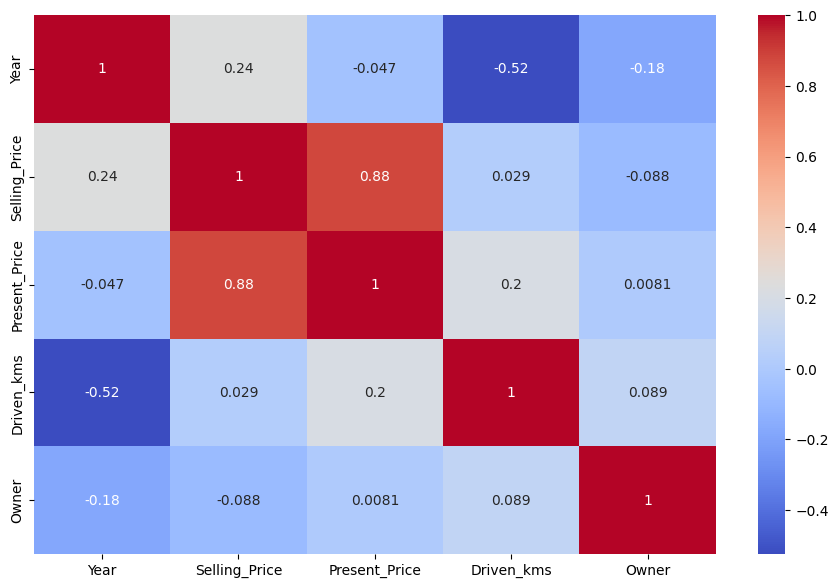

In [17]:
plt.figure(figsize=(11,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title="Correlation Heatmap"
plt.savefig("Correlation Heatmap.png",
            dpi=300,bbox_inches="tight")
plt.show()

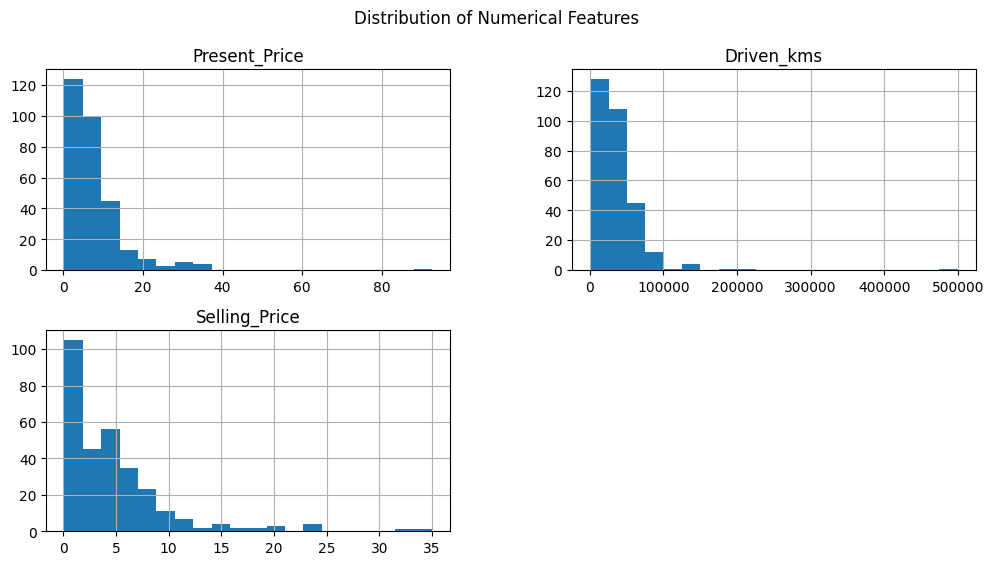

In [18]:
numerical_cols=["Present_Price","Driven_kms","Selling_Price"]
df[numerical_cols].hist(figsize=(12,6),bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.savefig("Distribution of Numerical Features.png",
            dpi=300,bbox_inches="tight")
plt.show()

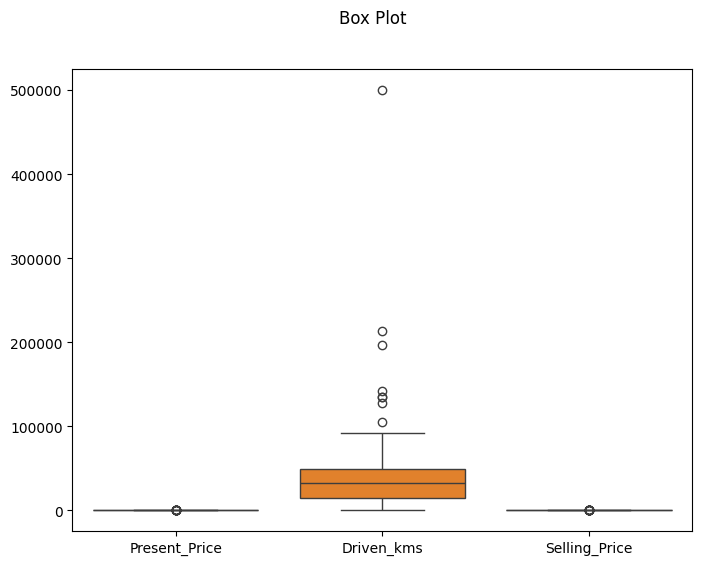

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[["Present_Price","Driven_kms","Selling_Price"]])
plt.suptitle("Box Plot")
plt.savefig("Box Plot.png",
            dpi=300,bbox_inches="tight")
plt.show()

In [20]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
sns.countplot(x='Fuel_Type_Diesel',data=df)
plt.suptitle("Diesel Count")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_test,x_train,y_test,y_train=train_test_split(x,y,train_size=0.1,random_state=42)

In [ ]:
x_test.shape

In [ ]:
x_train.shape

In [ ]:
df.shape

In [ ]:
y_test.shape

In [ ]:
y_train.shape

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
l=LinearRegression()
l.fit(x_train,y_train)

In [ ]:
y_pred=l.predict(x_test)

In [ ]:
print(f"MAE:{mean_absolute_error(y_test,y_pred)}")
print(f"MSE:{mean_squared_error(y_test,y_pred)}")
print(f"RMSE:{np.sqrt(mean_absolute_error(y_test,y_pred))}")
print(f"R2 score:{r2_score(y_test,y_pred)}")

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)

In [ ]:
print(f"MAE:{mean_absolute_error(y_test,y_pred_dt)}")
print(f"MSE:{mean_squared_error(y_test,y_pred_dt)}")
print(f"RMSE:{np.sqrt(mean_absolute_error(y_test,y_pred_dt))}")
print(f"R2 score:{r2_score(y_test,y_pred_dt)}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

In [ ]:
print(f"MAE:{mean_absolute_error(y_test,y_pred_rf)}")
print(f"MSE:{mean_squared_error(y_test,y_pred_rf)}")
print(f"RMSE:{np.sqrt(mean_absolute_error(y_test,y_pred_rf))}")
print(f"R2 score:{r2_score(y_test,y_pred_rf)}")

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb=XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=4,random_state=42)

In [ ]:
xgb.fit(x_train,y_train)
y_pred_xgb=xgb.predict(x_test)

In [ ]:
print(f"MAE:{mean_absolute_error(y_test,y_pred_xgb)}")
print(f"MSE:{mean_squared_error(y_test,y_pred_xgb)}")
print(f"RMSE:{np.sqrt(mean_absolute_error(y_test,y_pred_xgb))}")
print(f"R2 score:{r2_score(y_test,y_pred_xgb)}")

In [ ]:
from xgboost import plot_importance

In [ ]:
plt.figure(figsize=(10,9))
plot_importance(xgb)
plt.savefig(" Feature Importance.png",
            dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
importance=xgb.feature_importances_
plt.figure(figsize=(10,9))
plt.barh(x_train.columns,importance)
plt.suptitle("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
print(f"Train score: {xgb.score(x_train,y_train)}")
print(f"Test score: {xgb.score(x_test,y_test)}")

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(y_test,y_pred_xgb,alpha=0.7)
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],color="Red",linewidth=3
        )
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.suptitle("Actual Vs Predicted")
plt.savefig("Actual Vs Predicted.png",
            dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
residuals= y_test - y_pred_xgb
plt.figure(figsize=(7,5))
plt.scatter(y_pred_xgb,residuals)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.suptitle("Residual Plot")
plt.savefig("Residual Plot.png",
            dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
pkl.dump(xgb,open("Car_price_prediction","wb"))

In [ ]:
plt.savefig("Correlation Heatmap.png",
            dpi=300,bbox_inches="tight")
plt.show()
plt.savefig("Residual Plot.png",
            dpi=300,bbox_inches="tight")
plt.show()
plt.savefig("Box Plot.png",
            dpi=300,bbox_inches="tight")
plt.show()
plt.savefig("Distribution of Numerical Features.png",
            dpi=300,bbox_inches="tight")
plt.show()
plt.savefig("Importance.png",
            dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
import pickle

with open("Car_price_prediction.pkl", "wb") as file:
    pickle.dump(xgb, file)

print("✅ XGBoost model saved successfully!")

In [ ]:
with open("Car_price_prediction.pkl", "rb") as file:
    model = pkl.load(file)
print("✅ Model loaded successfully!")

In [ ]:
sample = np.array([[5.59, 3.35, 0, 1, 50000, 0, 8,9]])
prediction =xgb.predict(sample)
print("Predicted Selling Price:", prediction[0])